In [21]:
import sys

import ast
import anndata
import cassiopeia as cas
import matplotlib.pyplot as plt
import mplscience
import networkx as nx
import numpy as np
import pandas as pd
import pickle as pic
import scanpy as sc
import seaborn as sns
import squidpy as sq
import scipy
from scipy.spatial import distance
from scipy.cluster import hierarchy

from tqdm import tqdm

SPATIAL_PACKAGE="/path/to/spatial/package/"
DATA_DIR="/path/to/kpspatial/data/"
sys.path.append(SPATIAL_PACKAGE)

from utilities import target_site_utilities, spatial_utilities, tree_utilities, colors, phylodynamics, reconstruct

## Read in data

In [5]:
slidetags_fitness = pd.read_csv("./data/slidetags_fitness.tsv", sep='\t', index_col = 0)
slidetags_plasticity = pd.read_csv("./data/slidetags_plasticity.tsv", sep='\t', index_col=0)

non_tumor_states = ['Ciliated cell',
                    'Club cell', 
                    'AT2']

tumor_states = ['AT1-like',
              'AT2-like',
              'Early EMT',
              'Early gastric',
              'Endoderm-like',
              'Gastric-like',
              'High-plasticity cell state',
              'Late gastric',
              'Neuronal-like',
              'Pre-EMT']

early_states = ['AT1-like',
              'AT2-like']

late_states = ['Early EMT',
              'Early gastric',
              'Endoderm-like',
              'Gastric-like',
              'High-plasticity cell state',
              'Late gastric',
              'Neuronal-like',
              'Pre-EMT']

In [6]:
## Read in Slidetags trees

# LAYER, PUCK = 'Layer3', 'Puck1'
SLIDETAGS_SAMPLES = [('Layer1', 'Puck1'),
                   ('Layer2', 'Puck1'),
                   ('Layer3', 'Puck1'),
                   ('Layer3', 'Puck2'),
                   ('Layer4', 'Puck1')]

trees = {}
adata_to_merge = []
for i, sample in zip(range(len(SLIDETAGS_SAMPLES)), SLIDETAGS_SAMPLES):
    print(sample)    
    LAYER, PUCK = sample

    _adata = sc.read_h5ad(f'{DATA_DIRECTORY}/slidetags/expression/adata_slidetags.{LAYER}.{PUCK}.h5ad')
    _adata.obs['library_id'] = f'{LAYER}_{PUCK}'

    tree = pic.load(open(f'{DATA_DIRECTORY}/slidetags/trees/{PUCK}_{LAYER}_hybrid.pkl', 'rb'))
    state_to_indel = pic.load(open(f'{DATA_DIRECTORY}/slidetags/trees/{PUCK}_{LAYER}_state2indel.pkl', 'rb'))
    
    tree.cell_meta = _adata.obs.loc[tree.leaves]
    non_tumor_cells = np.setdiff1d(tree.leaves, tree.cell_meta[tree.cell_meta['cell_type'].isin(tumor_states)].index.values)
    tree.remove_leaves_and_prune_lineages(non_tumor_cells)

    _adata.obs['tumor'] = 'False'
    _adata.obs.loc[tree.leaves, 'tumor'] = 'True'

    adata_to_merge.append(_adata)
    trees[f'{LAYER}_{PUCK}'] = (tree, state_to_indel)

adata_combined = sc.concat(adata_to_merge)

adata_combined.obs['plasticity'] = np.nan
adata_combined.obs['fitness'] = np.nan
adata_combined.obs.loc[slidetags_plasticity.index, 'plasticity'] = slidetags_plasticity['scPlasticity']
adata_combined.obs.loc[slidetags_fitness.index, 'fitness'] = slidetags_fitness['fitness']
adata_combined.obs['library_id'] = adata_combined.obs['library_id'].astype('category')

adata_combined.layers['counts'] = adata_combined.X.copy()
adata_combined.layers['logged'] = adata_combined.X.copy()

# scale_factor = np.median(np.array(adata_combined.X.sum(axis=1)))
scale_factor = 1e6
sc.pp.normalize_total(adata_combined, target_sum=scale_factor, layer='logged')

sc.pp.log1p(adata_combined, layer='logged')

('Layer1', 'Puck1')
('Layer2', 'Puck1')
('Layer3', 'Puck1')
('Layer3', 'Puck2')
('Layer4', 'Puck1')


## Figure 3d-e

100%|██████████| 5/5 [00:24<00:00,  4.90s/it]


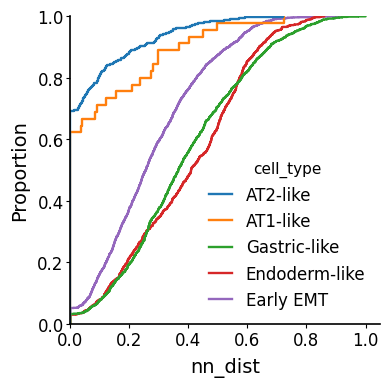

In [27]:
# Quantify distance to nearest boundary cell

cell_types = ['AT2-like', 'AT1-like', 'Gastric-like', 'Endoderm-like', 'Early EMT']

to_merge = []
for sample in tqdm(adata_combined.obs['library_id'].unique()):
    adata_sub = adata_combined[adata_combined.obs['library_id'] == sample]

    adata_sub = adata_sub[adata_sub.obs['tumor'] == 'True',:]
    
    for cell_type in (cell_types):
    
        cells = adata_sub[adata_sub.obs['cell_type'] == cell_type].obs_names
        boundary_cells = adata_sub[adata_sub.obs['tumor_id'] == 'non-tumor'].obs_names
        # boundary_cells = adata_sub[adata_sub.obs['tumor_boundary'] == 'True'].obs_names
        
        nn_dist = []
        for cell in cells:
            
            nn_dist.append(np.min((np.sum(np.abs(adata_sub[boundary_cells,:].obsm['spatial'] - adata_sub[cell,:].obsm['spatial']), axis=1))))
    
        to_merge.append(pd.DataFrame.from_dict({'cell_type': [cell_type]*len(nn_dist), 'nn_dist': nn_dist, 'sample': [sample]*len(nn_dist)}))

nn_dists = pd.concat(to_merge)
_ma, _mi = nn_dists['nn_dist'].max(), nn_dists['nn_dist'].min()
nn_dists['nn_dist'] = (nn_dists['nn_dist'] - _mi) / (_ma - _mi)

with mplscience.style_context():
    sns.ecdfplot(data=nn_dists, x='nn_dist', hue='cell_type')
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.0)
    plt.show()

### Extended Data Figure 6e

In [ ]:
# call all expansions

adata_combined.obs['expanding'] = np.nan
for library_id in adata_combined.obs['library_id'].unique():

    tree, _ = trees[library_id]
    adata_combined.obs.loc[tree.leaves, 'expanding'] = 'False'
    for tumor_id in tree.cell_meta['tumor_id'].unique():
        subtree = tree.copy()
        subtree.remove_leaves_and_prune_lineages(np.setdiff1d(tree.leaves, tree.cell_meta[tree.cell_meta['tumor_id'] == tumor_id].index.values))
        subtree.collapse_mutationless_edges(infer_ancestral_characters=True)
    
        cas.tl.compute_expansion_pvalues(subtree, min_clade_size=(0.15 * tree.n_cell), min_depth=2)
    
        probability_threshold = 0.01
        
        all_expanding_nodes = []
        for node in subtree.depth_first_traverse_nodes():
            if subtree.get_attribute(node, "expansion_pvalue") < probability_threshold:
                all_expanding_nodes.append(node)
        
        
        # find lowest expansions
        expanding_nodes = []
        for n in subtree.depth_first_traverse_nodes(postorder=True):
            if n in all_expanding_nodes:
                if np.any([(_n in all_expanding_nodes and _n != n) for _n in subtree.depth_first_traverse_nodes(postorder=False, source=n)]):
                    continue
                expanding_nodes.append(n)
            
        for expansion_node in expanding_nodes:
            expanding_cells = subtree.leaves_in_subtree(expansion_node)
            adata_combined.obs.loc[expanding_cells, 'expanding'] = 'True'
        
adata_combined.uns['expanding_colors'] = ['black', 'red']


/tmp/ipykernel_472100/2453766148.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _order = adata_combined.obs.groupby('cell_type').agg({'fitness': 'median'}).dropna().sort_values(by='fitness', ascending=False).index.values
/tmp/ipykernel_472100/2453766148.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_props = adata_combined.obs.groupby(['cell_type', 'expanding']).size()


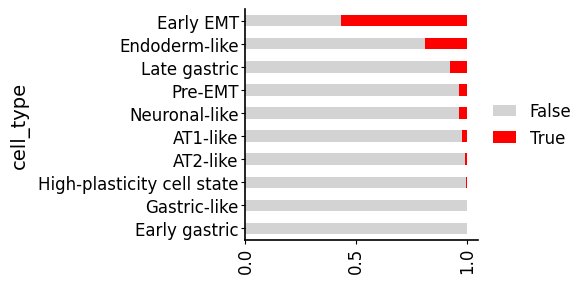

In [9]:
from matplotlib.colors import ListedColormap
adata_combined.obs['fitness'] = np.nan
adata_combined.obs.loc[slidetags_fitness.index, 'fitness'] = slidetags_fitness['fitness'].values

_order = adata_combined.obs.groupby('cell_type').agg({'fitness': 'median'}).dropna().sort_values(by='fitness', ascending=False).index.values

with mplscience.style_context():

    ct_props = adata_combined.obs.groupby(['cell_type', 'expanding']).size()
    ct_totals = adata_combined[~adata_combined.obs['expanding'].isna()].obs['cell_type'].value_counts()
    ct_props = ct_props.unstack()
    ct_props = ct_props.loc[ct_totals.index]
    ct_props = ct_props.apply(lambda x: x / ct_totals.loc[x.name], axis=1)

    _order = ct_props.sort_values(by='True', ascending=False).index.values
    color_map = ListedColormap(['#D3D3D3', 'red'])

    ct_props.loc[_order[::-1]].plot(kind='barh', stacked=True, colormap=color_map, figsize=(3,3))
    plt.xticks(rotation=90)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()
        

### Extended Data Figure 6h

In [10]:
slidetags_plasticity['library_id'] = adata_combined.obs.loc[slidetags_plasticity.index, 'library_id']
slidetags_plasticity['tumor_id'] = adata_combined.obs.loc[slidetags_plasticity.index, 'tumor_id']
slidetags_plasticity['cell_type'] = adata_combined.obs.loc[slidetags_plasticity.index, 'cell_type']

/tmp/ipykernel_472100/2004960563.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  collapsed_df = slidetags_plasticity.groupby(['library_id', 'tumor_id', 'cell_type']).agg({'scPlasticity': 'mean'}).dropna()
/tmp/ipykernel_472100/2004960563.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _order = collapsed_df.groupby('cell_type').agg({'scPlasticity': 'median'}).dropna().loc[tumor_states].sort_values(by='scPlasticity', ascending=True).index.values
/tmp/ipykernel_472100/2004960563.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` v

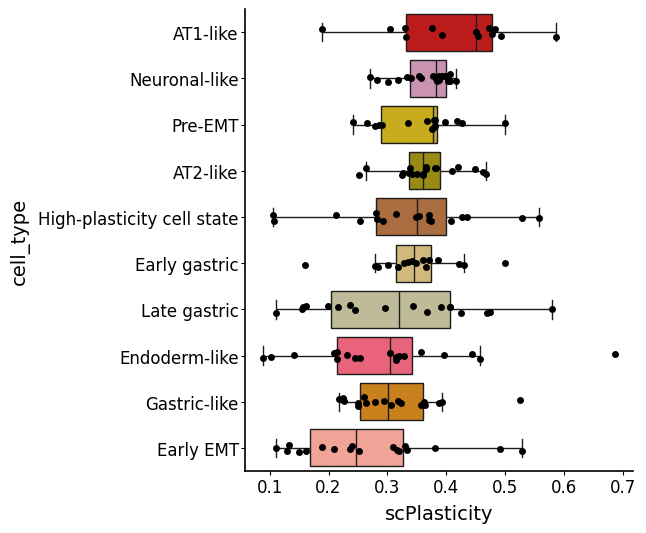

In [11]:
with mplscience.style_context():
    collapsed_df = slidetags_plasticity.groupby(['library_id', 'tumor_id', 'cell_type']).agg({'scPlasticity': 'mean'}).dropna()
    _order = collapsed_df.groupby('cell_type').agg({'scPlasticity': 'median'}).dropna().loc[tumor_states].sort_values(by='scPlasticity', ascending=True).index.values
    
    h=plt.figure(figsize=(5,6))
    sns.boxplot(data=collapsed_df, y='cell_type', x='scPlasticity', order=_order,fliersize=0, palette=colors.SLIDETAGS_COLORS)
    sns.stripplot(data=collapsed_df, y='cell_type', x='scPlasticity', order=_order, color='black', s=5)
    plt.gca().invert_yaxis()
    plt.show()

### Extended Data Figure 6i-j, Figure 3f

In [12]:
# inspect plasticities and autocorrelations

to_merge = []
for library_id in adata_combined.obs['library_id'].unique():

    adata_sub = adata_combined[(adata_combined.obs['library_id'] == library_id) & (adata_combined.obs['tumor_id'] != 'non-tumor')]
    for tumor in adata_sub.obs['tumor_id'].unique():

        tumor_adata = adata_sub[adata_sub.obs['tumor_id'] == tumor]
        tumor_adata = tumor_adata[(~tumor_adata.obs['fitness'].isna()) & (~tumor_adata.obs['plasticity'].isna()), :]

        sq.gr.spatial_neighbors(tumor_adata, coord_type="generic", spatial_key="spatial", library_key='library_id', n_neighs=min(len(tumor_adata)-1, 15), delaunay=False)

        
        expanding_cells = len(tumor_adata[tumor_adata.obs['expanding'] == 'True'].obs_names)
        
        autocorr_df = sq.gr.spatial_autocorr(tumor_adata, genes=['fitness', 'plasticity'], attr='obs', copy=True)

        new_df = autocorr_df['I'].reset_index()
        new_df['library_id'] = library_id
        new_df['tumor'] = tumor
        new_df['has_expansion'] = (expanding_cells > 5)
        to_merge.append(new_df)

autocorrelations = pd.concat(to_merge)
autocorrelations.columns = ['statistic', 'MoransI', 'library_id', 'tumor_id', 'has_expansion']
autocorrelations['library_tumor'] = autocorrelations.apply(lambda x: x.library_id  + "-" + x.tumor_id + str(x.has_expansion), axis=1)    

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view a

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/gr/_utils.py:194: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view a

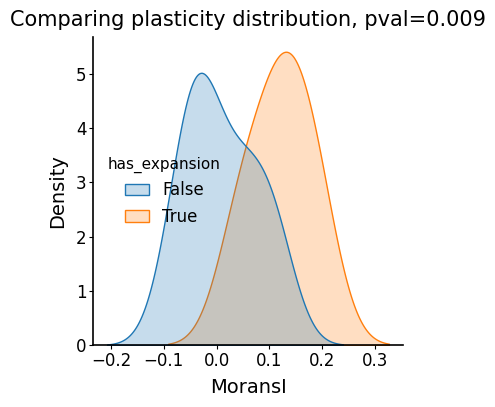

/tmp/ipykernel_472100/1856842280.py:22: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub, color=['plasticity'], spot_size=30, ax=ax, show=False, legend_loc=None, na_color='#D3D3D3')
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/tmp/ipykernel_472100/1856842280.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub[~adata_sub.obs['plasticity'].isna(),:], color=['plasticity'], spot_size=70, ax=ax, show=False, legend_loc=None, colorbar_loc=None, vmin='p1', vmax='p99')


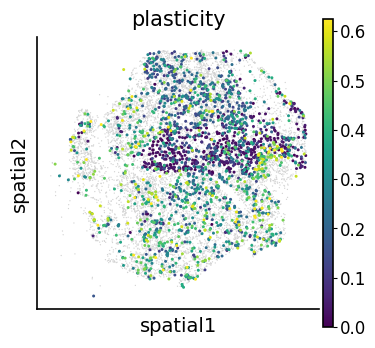

/tmp/ipykernel_472100/1856842280.py:29: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub, color=['expanding'], spot_size=30, ax=ax, show=False, legend_loc=None, na_color='#D3D3D3')
/tmp/ipykernel_472100/1856842280.py:30: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub[~adata_sub.obs['expanding'].isna(),:], color=['expanding'], spot_size=70, ax=ax, show=False, legend_loc=None, colorbar_loc=None, vmin='p1', vmax='p99')


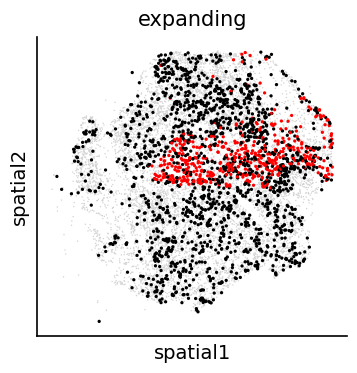

In [13]:
plasticity_autocorrelations = autocorrelations[autocorrelations['statistic'] == 'plasticity']
has_expansion = plasticity_autocorrelations.loc[plasticity_autocorrelations['has_expansion'] == True, 'MoransI'].values
no_expansion = plasticity_autocorrelations.loc[plasticity_autocorrelations['has_expansion'] == False, 'MoransI'].values


pval = scipy.stats.mannwhitneyu(has_expansion, no_expansion, alternative='greater')[1]

with mplscience.style_context():
    
    sns.kdeplot(plasticity_autocorrelations, x='MoransI', hue='has_expansion', fill='has_expansion',
                common_norm=False)
    plt.title(f'Comparing plasticity distribution, pval={round(pval, 3)}')
    plt.show()

with mplscience.style_context():

    library_id = 'Layer1_Puck1'
    adata_sub = adata_combined[adata_combined.obs['library_id'] == library_id]
    
    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()
    sc.pl.spatial(adata_sub, color=['plasticity'], spot_size=30, ax=ax, show=False, legend_loc=None, na_color='#D3D3D3')
    sc.pl.spatial(adata_sub[~adata_sub.obs['plasticity'].isna(),:], color=['plasticity'], spot_size=70, ax=ax, show=False, legend_loc=None, colorbar_loc=None, vmin='p1', vmax='p99')
    plt.gca().invert_yaxis()
    plt.show()

    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()
    sc.pl.spatial(adata_sub, color=['expanding'], spot_size=30, ax=ax, show=False, legend_loc=None, na_color='#D3D3D3')
    sc.pl.spatial(adata_sub[~adata_sub.obs['expanding'].isna(),:], color=['expanding'], spot_size=70, ax=ax, show=False, legend_loc=None, colorbar_loc=None, vmin='p1', vmax='p99')
    plt.gca().invert_yaxis()
    plt.show()

2.0963001662342224e-16


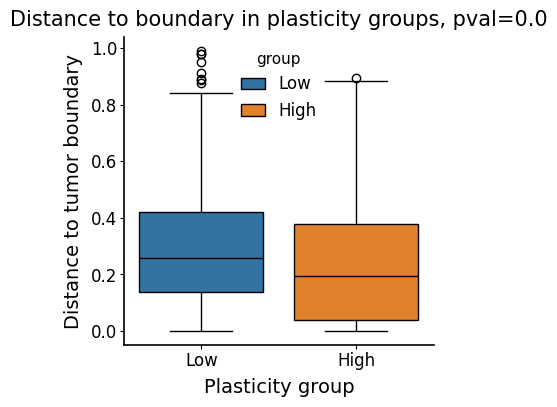

In [14]:
high = (slidetags_plasticity['scPlasticity'] >= slidetags_plasticity['scPlasticity'].quantile(0.75))
low = (slidetags_plasticity['scPlasticity'] < slidetags_plasticity['scPlasticity'].quantile(0.25))

slidetags_plasticity['group'] = None
slidetags_plasticity.loc[high, 'group'] = 'High'
slidetags_plasticity.loc[low, 'group'] = 'Low'

_ma, _mi = slidetags_plasticity['dist_to_boundary'].max(), slidetags_plasticity['dist_to_boundary'].min()
slidetags_plasticity['dist_to_boundary'] = (slidetags_plasticity['dist_to_boundary'] - _mi) / (_ma - _mi)

high_vals = slidetags_plasticity.loc[slidetags_plasticity['group'] == 'High', 'dist_to_boundary']
low_vals = slidetags_plasticity.loc[slidetags_plasticity['group'] == 'Low', 'dist_to_boundary']

pval = scipy.stats.mannwhitneyu(low_vals, high_vals, alternative='greater')[1]
print(pval)


with mplscience.style_context():

    sns.boxplot(data=slidetags_plasticity, x='group', y='dist_to_boundary', hue='group', linecolor='black')
    plt.xlabel('Plasticity group')
    plt.ylabel('Distance to tumor boundary')
    plt.title(f'Distance to boundary in plasticity groups, pval={round(pval, 3)}')
    plt.show()

### Figure 3e, Extended Data Figure 7a

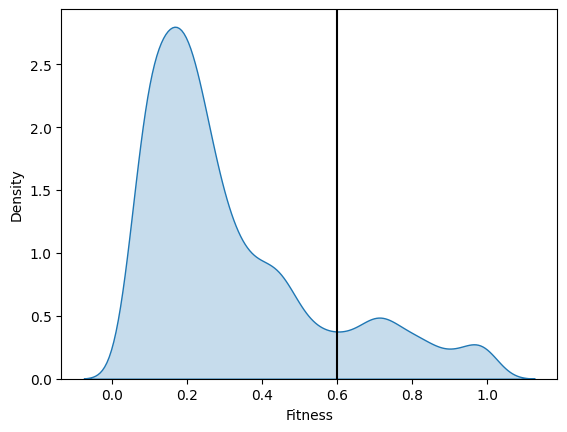

/tmp/ipykernel_472100/2317695547.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'High' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata_combined.obs.loc[adata_combined.obs['fitness'] >= threshold, 'fitness_level'] = 'High'


In [29]:
fitness_vals = adata_combined.obs['fitness'].values
fitness_vals = fitness_vals[~np.isnan(fitness_vals)]

threshold = np.nan
data = fitness_vals

eval_points = np.arange(0, 1, 0.01)
density = scipy.stats.gaussian_kde(data)(eval_points)
thresholds = eval_points[scipy.signal.argrelmin(density)]
threshold = thresholds[-2]

sns.kdeplot(fitness_vals, fill=True)
plt.xlabel("Fitness")
plt.axvline(x=threshold, color='black')
plt.show()

adata_combined.obs['fitness_level'] = np.nan
adata_combined.obs.loc[adata_combined.obs['fitness'] >= threshold, 'fitness_level'] = 'High'
adata_combined.obs.loc[adata_combined.obs['fitness'] < threshold, 'fitness_level'] = 'Low'

In [39]:
nn_dists = pd.DataFrame(columns = ['fitness', 'nn_dist', 'sample'])

summary_dfs = []
for library_id in adata_combined.obs['library_id'].unique():

    tree, _ = trees[library_id]
    adata_sub = adata_combined[adata_combined.obs['library_id'] == library_id]
    
    boundary_cells = adata_sub[(adata_sub.obs['library_id'] == library_id) & (adata_sub.obs['tumor_id'] == 'non-tumor')].obs_names

    nn_dist = []
    adata_sub.obs['nn_dist'] = np.nan
    for l in tqdm(tree.leaves):    
        
        nn_dist.append(np.min((np.sum(np.abs(adata_sub[boundary_cells,:].obsm['spatial'] - adata_sub[l,:].obsm['spatial']), axis=1))))

    adata_sub.obs.loc[tree.leaves, 'nn_dist'] = nn_dist
    _summary_df = adata_sub.obs.loc[~adata_sub.obs['nn_dist'].isna(), ['fitness', 'nn_dist', 'library_id', 'expanding']].copy()

    _ma, _mi = _summary_df['nn_dist'].max(), _summary_df['nn_dist'].min()
    _summary_df['nn_dist'] = (_summary_df['nn_dist'] - _mi) / (_ma - _mi)
    summary_dfs.append(_summary_df)

summary_df = pd.concat(summary_dfs)

/tmp/ipykernel_472100/3067046556.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['nn_dist'] = np.nan
100%|██████████| 2203/2203 [00:27<00:00, 80.17it/s]
/tmp/ipykernel_472100/3067046556.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['nn_dist'] = np.nan
100%|██████████| 797/797 [00:11<00:00, 68.40it/s]
/tmp/ipykernel_472100/3067046556.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['nn_dist'] = np.nan
100%|██████████| 1586/1586 [00:12<00:00, 127.11it/s]
/tmp/ipykernel_472100/3067046556.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['nn_dist'] = np.nan
100%|██████████| 265/265 [00:02<00:00, 120.36it/s]
/tmp/ipykernel_472100/3067046556.py:12: ImplicitModificationWarning: Trying to modify 

grouping
High    499
Low     499
Name: count, dtype: int64


/tmp/ipykernel_472100/1145394064.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Low' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[low, 'grouping'] = 'Low'


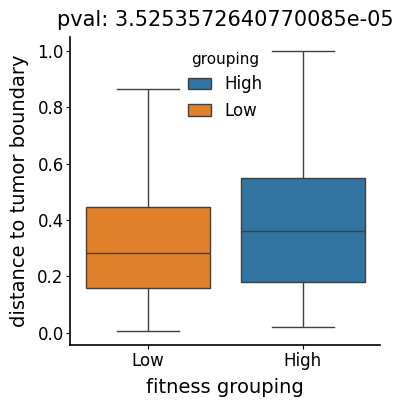

In [45]:
import colorcet as cc
import matplotlib as mpl
import scipy

summary_df['tumor_id'] = adata_combined.obs.loc[summary_df.index, 'tumor_id']
summary_df = summary_df[summary_df['tumor_id'] != 'non-tumor']

high = (summary_df['fitness'] >= summary_df['fitness'].quantile(0.90))
low = (summary_df['fitness'] <= summary_df['fitness'].quantile(0.10))

summary_df['grouping'] = np.nan
summary_df.loc[low, 'grouping'] = 'Low'
summary_df.loc[high, 'grouping'] = 'High'

print(summary_df['grouping'].value_counts())

pval = scipy.stats.mannwhitneyu(
                summary_df.loc[summary_df['grouping'] == 'High', 'nn_dist'].values,
                summary_df.loc[summary_df['grouping'] == 'Low', 'nn_dist'].values,
                alternative='greater')[1]

with mplscience.style_context():
    sns.boxplot(data=summary_df, x='grouping', y='nn_dist', hue='grouping', fliersize=0, order=['Low', 'High'])
    plt.ylabel('distance to tumor boundary')
    plt.xlabel('fitness grouping')
    plt.title(f'pval: {pval}')
    plt.show()

In [16]:
sq.gr.spatial_neighbors(adata_combined, coord_type="generic", spatial_key="spatial", library_key='library_id', n_neighs=20, delaunay=False)

spatial_graph = nx.from_numpy_array(adata_combined.obsp['spatial_connectivities'])
node_map = dict(zip(range(adata_combined.obsp['spatial_connectivities'].shape[0]), adata_combined.obs_names))
spatial_graph = nx.relabel_nodes(spatial_graph, node_map)

cells_near_fit = []
fit_cells = adata_combined[adata_combined.obs['fitness_level'] == 'High'].obs_names
for cell in fit_cells:
    neighborhood = [node for (_, node) in nx.bfs_edges(spatial_graph, cell, depth_limit=1)]

    cells_near_fit += neighborhood
cells_near_fit = np.unique(cells_near_fit)

cells_near_low_fit = []
low_fit_cells = adata_combined[adata_combined.obs['fitness_level'] == 'Low'].obs_names
for cell in low_fit_cells:
    neighborhood = [node for (_, node) in nx.bfs_edges(spatial_graph, cell, depth_limit=1)]

    cells_near_low_fit += neighborhood
    
cells_near_fit = np.unique(cells_near_fit)
cells_near_low_fit = np.setdiff1d(np.unique(cells_near_low_fit), cells_near_fit)

print(len(cells_near_fit))

INFO     Creating graph using `generic` coordinates and `None` transform and `5` libraries.                        
10055


/tmp/ipykernel_472100/4085264310.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'High' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata_combined.obs.loc[cells_near_fit, 'fitness_neighborhood'] = 'High'
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarnin

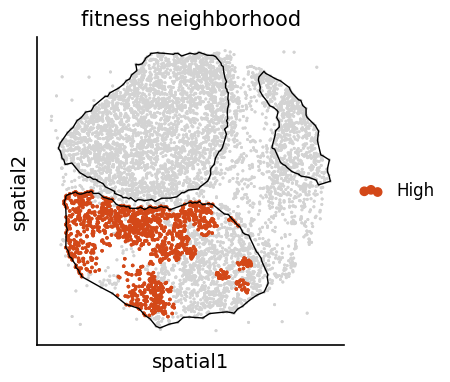

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


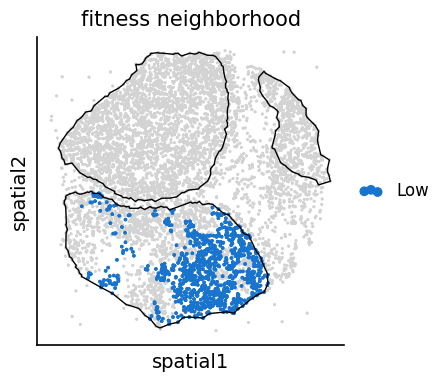

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


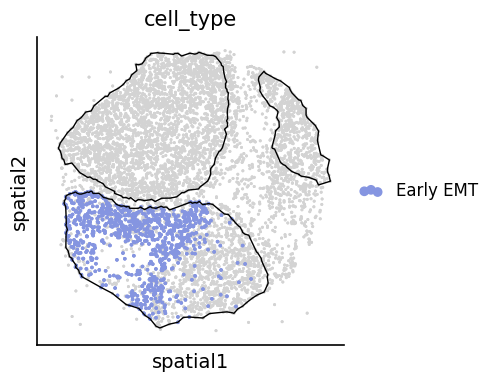

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


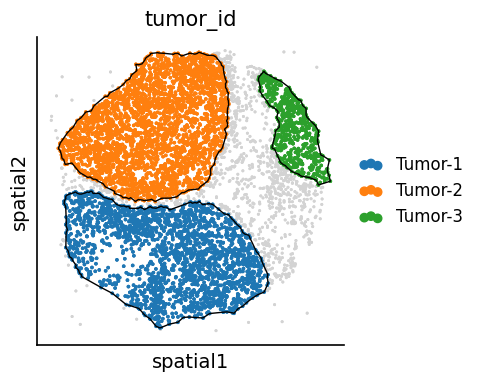

In [17]:
adata_combined.uns['fitness_neighborhood_colors'] = ['#D34818', '#1874CD']

adata_combined.obs['fitness_neighborhood'] = np.nan
adata_combined.obs.loc[cells_near_fit, 'fitness_neighborhood'] = 'High'
adata_combined.obs.loc[cells_near_low_fit, 'fitness_neighborhood'] = 'Low'

with mplscience.style_context():
    library_id, focus_tumor = "Layer3_Puck1", 'Tumor-1'
    
    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()
    sq.pl.spatial_scatter(adata_combined, library_key='library_id', library_id=library_id, size=5, shape=None, na_color='lightgray', ax=ax, figsize=(7,7), legend_loc=None)
    sq.pl.spatial_scatter(adata_combined[adata_combined.obs['tumor_id'] == focus_tumor], library_key='library_id', library_id=library_id, color=['fitness_neighborhood'],
                          groups = ["High"],
                          size=10, ax=ax, shape=None)
    for tumor in adata_combined[adata_combined.obs['library_id'] == library_id].obs['tumor_id'].unique():
            if tumor != 'non-tumor':
                spatial_utilities.plot_boundary(adata_combined[adata_combined.obs['library_id'] == library_id], ax=ax, color='black', tumor_id=tumor, max_distance=1e6)
    plt.gca().invert_yaxis()
    plt.title(f'fitness neighborhood')
    plt.show()
    
    library_id = "Layer3_Puck1"
    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()
    sq.pl.spatial_scatter(adata_combined, library_key='library_id', library_id=library_id, size=5, shape=None, na_color='lightgray', ax=ax, figsize=(7,7), legend_loc=None)
    sq.pl.spatial_scatter(adata_combined[adata_combined.obs['tumor_id'] == focus_tumor], library_key='library_id', library_id=library_id, color=['fitness_neighborhood'],
                          groups = ["Low"],
                          size=10, ax=ax, shape=None)
    for tumor in adata_combined[adata_combined.obs['library_id'] == library_id].obs['tumor_id'].unique():
            if tumor != 'non-tumor':
                spatial_utilities.plot_boundary(adata_combined[adata_combined.obs['library_id'] == library_id], ax=ax, color='black', tumor_id=tumor, max_distance=1e6)
    plt.gca().invert_yaxis()
    plt.title(f'fitness neighborhood')
    plt.show()
    
    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()
    sq.pl.spatial_scatter(adata_combined, library_key='library_id', library_id=library_id, size=5, shape=None, na_color='lightgray', ax=ax, figsize=(7,7), legend_loc=None)
    sq.pl.spatial_scatter(adata_combined[adata_combined.obs['tumor_id'] == focus_tumor], library_key='library_id', library_id=library_id, color=['cell_type'],
                          groups=['Early EMT'],
                          size=10, ax=ax, shape=None)
    for tumor in adata_combined[adata_combined.obs['library_id'] == library_id].obs['tumor_id'].unique():
            if tumor != 'non-tumor':
                spatial_utilities.plot_boundary(adata_combined[adata_combined.obs['library_id'] == library_id], ax=ax, color='black', tumor_id=tumor, max_distance=1e6)
    plt.gca().invert_yaxis()
    plt.show()
    
    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()
    sq.pl.spatial_scatter(adata_combined, library_key='library_id', library_id=library_id, size=5, shape=None, na_color='lightgray', ax=ax, figsize=(7,7), legend_loc=None)
    sq.pl.spatial_scatter(adata_combined[adata_combined.obs['tumor_id'] != 'non-tumor'], library_key='library_id', library_id=library_id, color=['tumor_id'],
                          size=10, ax=ax, shape=None)
    for tumor in adata_combined[adata_combined.obs['library_id'] == library_id].obs['tumor_id'].unique():
            if tumor != 'non-tumor':
                spatial_utilities.plot_boundary(adata_combined[adata_combined.obs['library_id'] == library_id], ax=ax, color='black', tumor_id=tumor, max_distance=1e6)
    plt.gca().invert_yaxis()
    plt.show()


## Extended Data figure 6b-c

/tmp/ipykernel_472100/1728229166.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'low-fitness' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata_combined_de.obs.loc[np.intersect1d(focus_cells, cells_near_low_fit), 'fitness_neighborhood'] = 'low-fitness'
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:291: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_counts"] = number


fitness_neighborhood
low-fitness     1287
high-fitness     398
Name: count, dtype: int64
Proceeding with DE of 1685 cells across 10000 genes


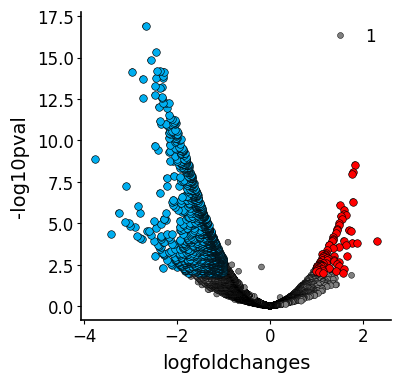

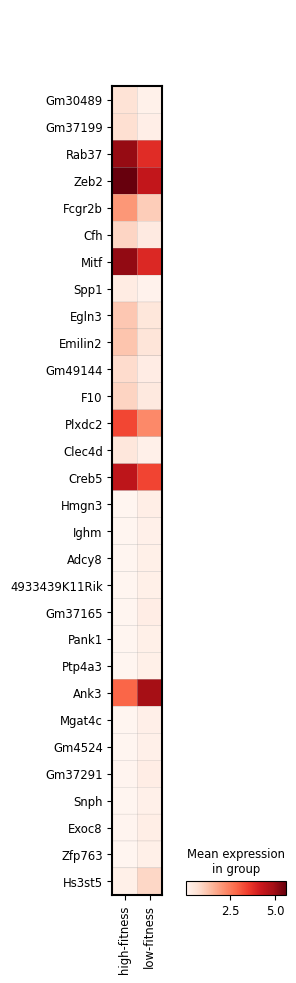

       names    scores  logfoldchanges         pvals     pvals_adj  -log10pval
22   Gm30489  4.498672        2.299123  8.655627e-06  1.258085e-04    3.900290
24   Gm37199  4.424862        1.883102  1.189810e-05  1.638856e-04    3.785459
0      Rab37  6.733300        1.825686  3.376454e-11  2.910736e-09    8.535997
1       Zeb2  6.536810        1.784926  1.204805e-10  8.252087e-09    8.083436
3     Fcgr2b  5.773757        1.784482  1.289051e-08  4.901336e-07    6.309686
23       Cfh  4.445564        1.773914  1.081432e-05  1.510380e-04    3.820914
2       Mitf  6.489263        1.764632  1.646189e-10  1.097459e-08    7.959612
100     Spp1  3.025682        1.755467  2.611479e-03  1.397225e-02    1.854734
15     Egln3  4.878136        1.747221  1.433860e-06  2.777336e-05    4.556372
13   Emilin2  4.892716        1.690907  1.327740e-06  2.603411e-05    4.584457
37   Gm49144  3.926722        1.657744  9.831726e-05  9.782812e-04    3.009536
27       F10  4.345286        1.635818  1.677608e-05

In [19]:
# run cell-type aware differential expression
adata_combined_de = adata_combined.copy()

focus_cells = adata_combined_de.obs_names

adata_combined_de.obs['fitness_neighborhood'] = np.nan
adata_combined_de.obs.loc[np.intersect1d(focus_cells, cells_near_low_fit), 'fitness_neighborhood'] = 'low-fitness'
adata_combined_de.obs.loc[np.intersect1d(focus_cells, cells_near_fit), 'fitness_neighborhood'] = 'high-fitness'

adata_combined_de = adata_combined_de[~adata_combined_de.obs['fitness_neighborhood'].isna()]

cell_types = ['MonoMac', 'Mac', 'Alveolar Macrophage', 'Pecam1+ Mac']
adata_combined_de = adata_combined_de[adata_combined_de.obs['cell_type'].isin(cell_types),:]

print(adata_combined_de.obs['fitness_neighborhood'].value_counts())

sc.pp.filter_genes(adata_combined_de, min_counts=50)
sc.pp.highly_variable_genes(
    adata_combined_de,
    n_top_genes=10000,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
)

print(f'Proceeding with DE of {len(adata_combined_de.obs_names)} cells across {len(adata_combined_de.var_names)} genes')

sc.tl.rank_genes_groups(adata_combined_de,
                        groupby='fitness_neighborhood',
                        layer='logged',
                        method='t-test',
                        reference='low-fitness',
                        use_raw=False,
                        tie_correct=True)


de_df = sc.get.rank_genes_groups_df(adata_combined_de, group="high-fitness")
de_df['-log10pval'] = -np.log10(de_df['pvals_adj'])

FC_CUTOFF = 1

with mplscience.style_context():
    sns.scatterplot(de_df, x='logfoldchanges', y='-log10pval', edgecolor='black', size=1, color='gray')
    sns.scatterplot(de_df[(de_df['-log10pval'] > -np.log10(0.01)) & (de_df['logfoldchanges'] > FC_CUTOFF)], x='logfoldchanges', y='-log10pval', edgecolor='black', s=30, color='red')
    sns.scatterplot(de_df[(de_df['-log10pval'] > -np.log10(0.01)) & (de_df['logfoldchanges'] < -FC_CUTOFF)], x='logfoldchanges', y='-log10pval', edgecolor='black', s=30, color='#00AEEF')    
    plt.show()

up_genes = de_df[(de_df['-log10pval'] > -np.log10(0.05)) & (de_df['logfoldchanges'] > FC_CUTOFF)]
down_genes = de_df[(de_df['-log10pval'] > -np.log10(0.05)) & (de_df['logfoldchanges'] < -FC_CUTOFF)]

up_gene_names = list(up_genes.sort_values(by='logfoldchanges', ascending=False).head(15)['names'])
down_gene_names = list(down_genes.sort_values(by='logfoldchanges', ascending=True).head(15)['names'])

all_genes = de_df[(de_df['-log10pval'] > -np.log10(0.01)) & (np.abs(de_df['logfoldchanges']) > FC_CUTOFF)]
# all_genes.to_csv(f'./data/fitness_de_macrophages.tsv', sep='\t')


print(up_genes.sort_values(by='logfoldchanges', ascending=False).head(40))
print(down_genes.sort_values(by='-log10pval', ascending=True).head(40))

/tmp/ipykernel_472100/1383971225.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'high-fitness' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata_combined_de.obs.loc[cells_near_fit, 'fitness_neighborhood'] = 'high-fitness'
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:291: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_counts"] = number


fitness_neighborhood
low-fitness     603
high-fitness    348
Name: count, dtype: int64
Proceeding with DE of 951 cells across 6753 genes


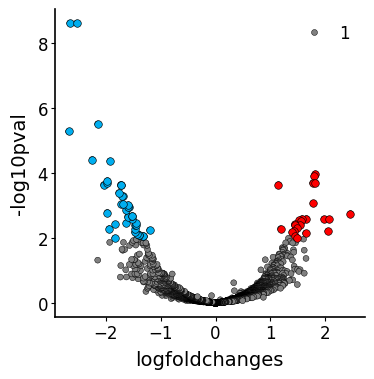

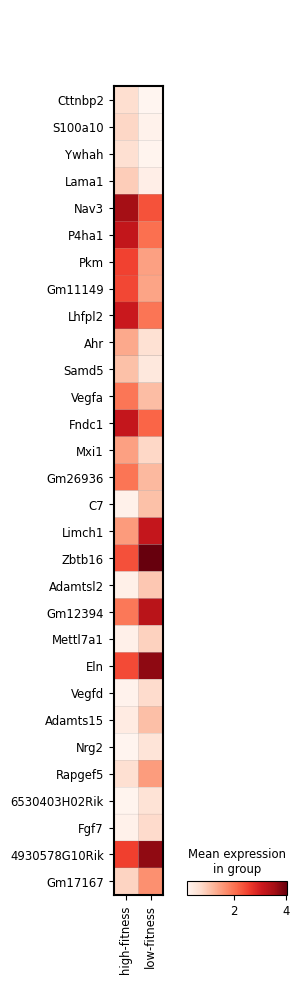

         names    scores  logfoldchanges         pvals  pvals_adj  -log10pval
0        P4ha1  5.371681        1.819012  1.081792e-07   0.000104    3.981457
1          Pkm  5.317184        1.791924  1.457656e-07   0.000123    3.909938
2       Lhfpl2  5.146949        1.770645  3.483480e-07   0.000197    3.704568
3         Nav3  5.145176        1.821449  3.508463e-07   0.000197    3.704568
4        Cald1  5.067769        1.146426  4.898625e-07   0.000225    3.648700
5      Gm11149  4.753073        1.777110  2.487935e-06   0.000840    3.075694
6      Cttnbp2  4.538311        2.459608  7.266526e-06   0.001753    2.756334
7          Ahr  4.415870        1.656567  1.204903e-05   0.002495    2.602898
8        Vegfa  4.410012        1.577195  1.219324e-05   0.002495    2.602898
9        Lama1  4.405776        1.974966  1.288135e-05   0.002558    2.592021
10     S100a10  4.390976        2.069726  1.383296e-05   0.002595    2.585891
11     Gm26936  4.355550        1.527803  1.551794e-05   0.00283

In [20]:
# run cell-type aware differential expression
adata_combined_de = adata_combined.copy()

adata_combined_de.obs['fitness_neighborhood'] = np.nan
adata_combined_de.obs.loc[cells_near_fit, 'fitness_neighborhood'] = 'high-fitness'
adata_combined_de.obs.loc[cells_near_low_fit, 'fitness_neighborhood'] = 'low-fitness'

adata_combined_de = adata_combined_de[~adata_combined_de.obs['fitness_neighborhood'].isna()]

cell_types = ['iCAF', 'myCAF', 'Mesothelial']
adata_combined_de = adata_combined_de[adata_combined_de.obs['cell_type'].isin(cell_types),:]

print(adata_combined_de.obs['fitness_neighborhood'].value_counts())

sc.pp.filter_genes(adata_combined_de, min_counts=50)

sc.pp.highly_variable_genes(
    adata_combined_de,
    n_top_genes=10000,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
)

print(f'Proceeding with DE of {len(adata_combined_de.obs_names)} cells across {len(adata_combined_de.var_names)} genes')

sc.tl.rank_genes_groups(adata_combined_de,
                        groupby='fitness_neighborhood',
                        layer='logged',
                        method='t-test',
                        reference='low-fitness',
                        use_raw=False,
                        tie_correct=True)


de_df = sc.get.rank_genes_groups_df(adata_combined_de, group="high-fitness")
de_df['-log10pval'] = -np.log10(de_df['pvals_adj'])

FC_CUTOFF = 1

with mplscience.style_context():
    sns.scatterplot(de_df, x='logfoldchanges', y='-log10pval', edgecolor='black', size=1, color='gray')
    sns.scatterplot(de_df[(de_df['-log10pval'] > -np.log10(0.01)) & (de_df['logfoldchanges'] > FC_CUTOFF)], x='logfoldchanges', y='-log10pval', edgecolor='black', s=30, color='red')
    sns.scatterplot(de_df[(de_df['-log10pval'] > -np.log10(0.01)) & (de_df['logfoldchanges'] < -FC_CUTOFF)], x='logfoldchanges', y='-log10pval', edgecolor='black', s=30, color='#00AEEF')
    plt.show()

up_genes = de_df[(de_df['-log10pval'] > -np.log10(0.01)) & (de_df['logfoldchanges'] > FC_CUTOFF)]
down_genes = de_df[(de_df['-log10pval'] > -np.log10(0.01)) & (de_df['logfoldchanges'] < -FC_CUTOFF)]

up_gene_names = list(up_genes.sort_values(by='logfoldchanges', ascending=False).head(15)['names'])
down_gene_names = list(down_genes.sort_values(by='logfoldchanges', ascending=True).head(15)['names'])

all_genes = de_df[(de_df['-log10pval'] > -np.log10(0.01)) & (np.abs(de_df['logfoldchanges']) > FC_CUTOFF)]
# all_genes.to_csv(f'./data/fitness_de_fibroblasts.tsv', sep='\t')

print(up_genes.sort_values(by='-log10pval', ascending=False).head(30))
print(down_genes.sort_values(by='-log10pval', ascending=False).head(30))

### Figure 4a

/tmp/ipykernel_472100/858296910.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for lib, grp in adata_combined.obs.groupby('library_id'):


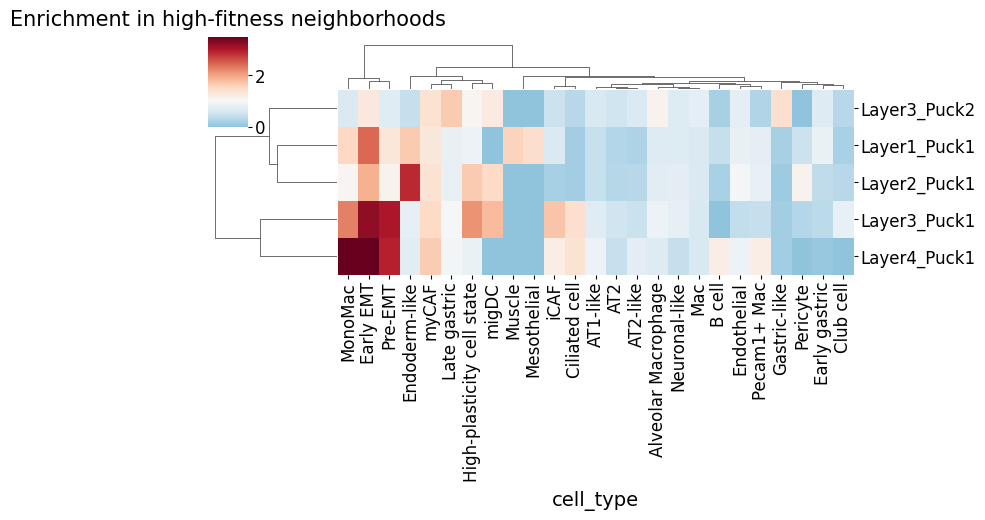

In [18]:
freqs = adata_combined.obs.loc[cells_near_fit, 'cell_type'].value_counts()

fraction = len(cells_near_fit) / len(adata_combined.obs_names)

expected_values = adata_combined.obs['cell_type'].value_counts() * fraction
enrichments = (freqs / expected_values.loc[freqs.index.values]).sort_values(ascending=False)

# for each array
to_merge = []
samp_names = []
for lib, grp in adata_combined.obs.groupby('library_id'):

    _cells_near_fit = np.intersect1d(cells_near_fit, grp.index.values)
    freqs = grp.loc[np.intersect1d(_cells_near_fit, grp.index.values), 'cell_type'].value_counts()
    
    fraction = len(_cells_near_fit) / len(grp)
    
    expected_values = grp['cell_type'].value_counts() * fraction
    enrichments = (freqs / expected_values.loc[freqs.index.values]).sort_values(ascending=False)

    to_merge.append(enrichments)
    samp_names.append(lib)

per_puck_enrichments = pd.concat(to_merge, axis=1)
per_puck_enrichments.columns = samp_names

with mplscience.style_context():
    per_puck_enrichments.fillna(0, inplace=True)
    sns.clustermap(per_puck_enrichments.T.astype(float),
                   cmap='RdBu_r', figsize=(8, 5), vmin=0, vmax=3.5, center=1,
                   method='ward')
    plt.title("Enrichment in high-fitness neighborhoods")
    plt.show()
